# ***Loading Data***

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mariumaabdelrahman","key":"f4b146e5f07b55802140218289a11b07"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d urbikn/sroie-datasetv2

Dataset URL: https://www.kaggle.com/datasets/urbikn/sroie-datasetv2
License(s): other
100% 834M/834M [00:23<00:00, 37.4MB/s]



In [5]:
import zipfile

zip_path = "sroie-datasetv2.zip"
extract_path = "/content/SROIE"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [7]:
import os

dataset_path = "/content/SROIE"

for root, dirs, files in os.walk(dataset_path):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("-"*50)

/content/SROIE
Folders: ['SROIE2019']
Files: []
--------------------------------------------------
/content/SROIE/SROIE2019
Folders: ['train', 'test', 'layoutlm-base-uncased']
Files: []
--------------------------------------------------
/content/SROIE/SROIE2019/train
Folders: ['box', 'entities', 'img']
Files: []
--------------------------------------------------
/content/SROIE/SROIE2019/train/box
Folders: []
Files: ['X51005442378.txt', 'X51005719882.txt', 'X00016469623.txt', 'X51005806716.txt', 'X51006556732.txt']
--------------------------------------------------
/content/SROIE/SROIE2019/train/entities
Folders: []
Files: ['X51005442378.txt', 'X51005719882.txt', 'X00016469623.txt', 'X51005806716.txt', 'X51006556732.txt']
--------------------------------------------------
/content/SROIE/SROIE2019/train/img
Folders: []
Files: ['X51007339130.jpg', 'X51005433522.jpg', 'X51008142030.jpg', 'X51006388066.jpg', 'X51007339639.jpg']
--------------------------------------------------
/content/SRO

In [8]:
train_img_dir = "/content/SROIE/SROIE2019/train/img"
train_box_dir = "/content/SROIE/SROIE2019/train/box"

test_img_dir = "/content/SROIE/SROIE2019/test/img"
test_box_dir = "/content/SROIE/SROIE2019/test/box"

In [9]:
images = sorted([
    f for f in os.listdir(train_img_dir)
    if f.lower().endswith(('.jpg', '.png', '.jpeg'))
])

print("Total training images:", len(images))

Total training images: 626


# ***Exploring Data***

In [16]:
import os

total_images = 0

# Create a dictionary to hold the paths and their display names
image_categories = {
    "Train Images": train_img_dir,
    "Test Images": test_img_dir,
}

for cls_name, cls_path in image_categories.items():
    if not os.path.isdir(cls_path):
        print(f"Warning: Directory not found: {cls_path}")
        continue

    # Filter for actual image files
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.jfif'))]

    num_images = len(images)
    total_images += num_images

    print(f"{cls_name}: {num_images} images")

print("\nTotal images:", total_images)

Train Images: 626 images
Test Images: 347 images

Total images: 973


# ***Preprocessing Data***

In [21]:
import cv2
import matplotlib.pyplot as plt
import random
import os

train_img_dir = "/content/SROIE/SROIE2019/train/img"

def show_before_after(image_dir, process_func,
                      title="Processed",
                      num_images=3):

    images = [
        f for f in os.listdir(image_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    sample_images = random.sample(
        images,
        min(num_images, len(images))
    )

    for img_name in sample_images:

        img_path = os.path.join(image_dir, img_name)

        img = cv2.imread(img_path)

        if img is None:
            continue

        processed = process_func(img)

        plt.figure(figsize=(10,4))

        # Original
        plt.subplot(1,2,1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Original")
        plt.axis("off")

        # Processed
        plt.subplot(1,2,2)
        plt.imshow(processed, cmap='gray')
        plt.title(title)
        plt.axis("off")

        plt.suptitle(img_name)
        plt.show()

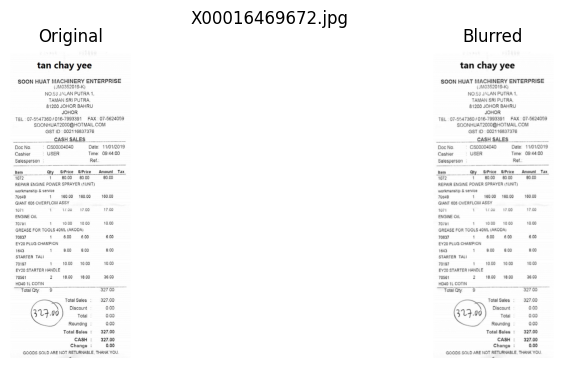

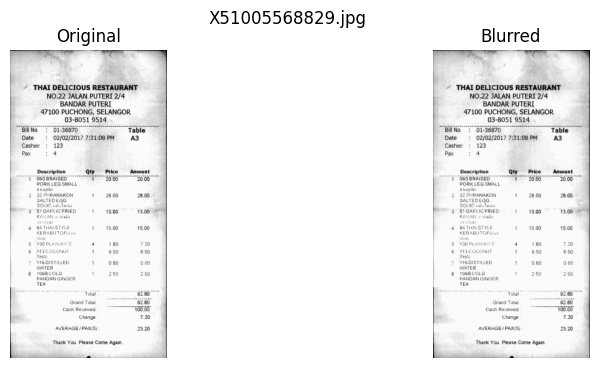

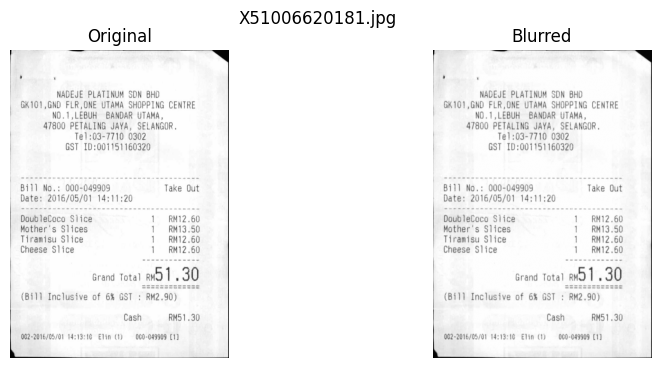

In [22]:
def blur_process(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.GaussianBlur(gray, (3,3), 0)

show_before_after(
    train_img_dir,
    blur_process,
    "Blurred"
)

# ***Edge Detection***

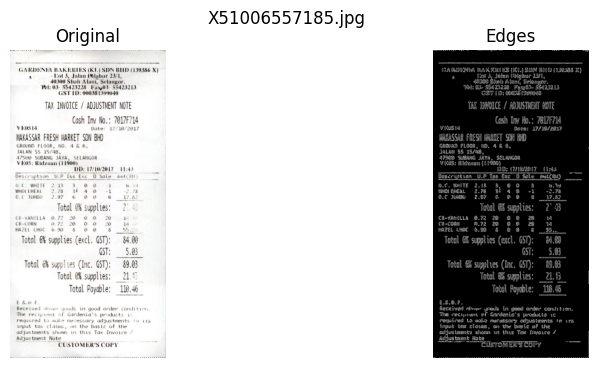

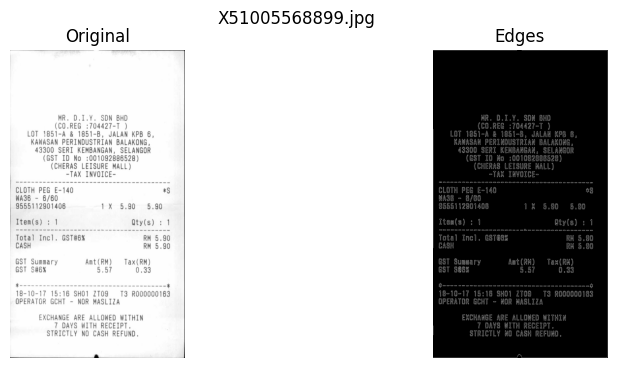

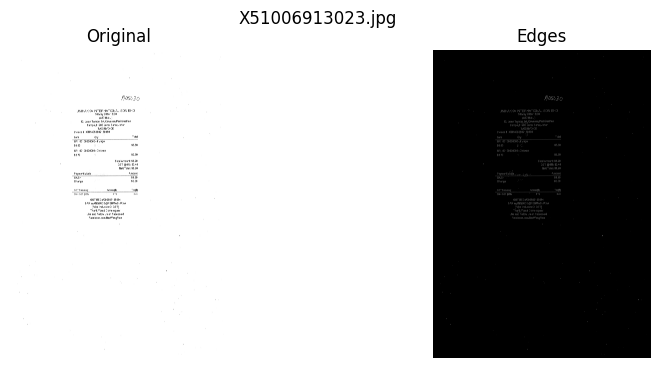

In [24]:
def edge_process(img):

    img = blur_process(img)

    return cv2.Canny(img, 50, 150)

show_before_after(
    train_img_dir,
    edge_process,
    "Edges"
)

# **Contours and perspective transform**

In [25]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import urllib.request

dataset_path = "/content/SROIE/SROIE2019"

train_img_dir = os.path.join(dataset_path, "train/img")
train_box_dir = os.path.join(dataset_path, "train/box")

test_img_dir = os.path.join(dataset_path, "test/img")
test_box_dir = os.path.join(dataset_path, "test/box")

# METHOD 1 — U2Net deep salient object detection

In [26]:
#Download model
def download_model_if_needed():

    model_dir  = "models"
    model_path = os.path.join(model_dir, "u2net_doc.onnx")
    os.makedirs(model_dir, exist_ok=True)

    if not os.path.exists(model_path):
        print("Downloading U2Net document segmentation model...")
        url = "https://github.com/danielgatis/rembg/releases/download/v0.0.0/u2net.onnx"
        urllib.request.urlretrieve(url, model_path)
        print("Download complete.")

    return model_path

In [27]:
def order_points(pts):
    pts    = pts.reshape(4, 2).astype(np.float32)
    center = pts.mean(axis=0)
    angles = np.arctan2(pts[:, 1] - center[1], pts[:, 0] - center[0])
    pts    = pts[np.argsort(angles)]
    start  = np.argmin(pts.sum(axis=1))
    pts    = np.roll(pts, -start, axis=0)
    return pts.astype("float32")


In [28]:
def four_point_warp(image, pts):
    rect = order_points(pts)
    tl, tr, br, bl = rect
    w1 = np.linalg.norm(br - bl)
    w2 = np.linalg.norm(tr - tl)
    h1 = np.linalg.norm(tr - br)
    h2 = np.linalg.norm(tl - bl)
    max_w = max(int(w1), int(w2))
    max_h = max(int(h1), int(h2))
    if max_w == 0 or max_h == 0:
        return image
    dst = np.array([
        [0,         0        ],
        [max_w - 1, 0        ],
        [max_w - 1, max_h - 1],
        [0,         max_h - 1],
    ], dtype="float32")
    M      = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (max_w, max_h))
    avg_w  = (w1 + w2) / 2
    avg_h  = (h1 + h2) / 2
    if avg_w > avg_h * 1.2:
        warped = cv2.rotate(warped, cv2.ROTATE_90_CLOCKWISE)
    return warped

In [29]:
def border_contour(img):
    h, w = img.shape[:2]
    pad  = 4
    return np.array([
        [pad,     pad    ],
        [w - pad, pad    ],
        [w - pad, h - pad],
        [pad,     h - pad],
    ], dtype=np.float32)

In [30]:
#Take the best quad from binary mask



def quad_from_mask(mask, total_area, img_shape):

    candidates = []
    kernel     = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    mask       = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=4)
    mask       = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=2)

    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None

    cnts = sorted(cnts, key=cv2.contourArea, reverse=True)[:3]

    for c in cnts:
        area = cv2.contourArea(c)
        if area < total_area * 0.05:
            continue

        hull = cv2.convexHull(c)
        peri = cv2.arcLength(hull, True)

        for eps in [0.01, 0.02, 0.03, 0.05, 0.08, 0.12]:
            approx = cv2.approxPolyDP(hull, eps * peri, True)
            if len(approx) == 4:
                pts = order_points(approx.reshape(4, 2))
                candidates.append(pts)
                break

        # If we couldn't get 4 points, fit a bounding rect
        if not candidates:
            rect    = cv2.minAreaRect(c)
            box     = cv2.boxPoints(rect)
            pts     = order_points(box)
            candidates.append(pts)

    if not candidates:
        return None

    # Pick candidate with best area coverage
    def score(pts):
        area = cv2.contourArea(pts.reshape(-1, 1, 2).astype(np.int32))
        return abs(area - total_area * 0.6)   # prefer ~60% coverage

    return min(candidates, key=score)

In [31]:
#Runs U2net to make a sailency/foreground mask
def u2net_segment(img_bgr, model_path):

    net = cv2.dnn.readNetFromONNX(model_path)

    h, w    = img_bgr.shape[:2]
    inp_sz  = 320
    blob    = cv2.dnn.blobFromImage(
        img_bgr, 1.0 / 255.0,
        (inp_sz, inp_sz),
        (0.485, 0.456, 0.406),   # ImageNet mean
        swapRB=True, crop=False
    )
    # Normalize std
    blob[0, 0] /= 0.229
    blob[0, 1] /= 0.224
    blob[0, 2] /= 0.225

    net.setInput(blob)
    out    = net.forward()          # shape (1, 1, 320, 320)
    pred   = out[0, 0]              # (320, 320)

    # Normalize to 0-255
    pred   = (pred - pred.min()) / (pred.max() - pred.min() + 1e-6)
    mask   = (pred * 255).astype(np.uint8)
    mask   = cv2.resize(mask, (w, h))

    # Threshold
    _, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    return mask_bin  #return uint8 mask 0-255 in input size


# **#METHOD 2 — Classic CV fallback (multi-strategy)**

In [32]:
#Use it when deep learning fails

def classic_segment(img_res, total_area):

    h, w  = img_res.shape[:2]
    gray  = cv2.cvtColor(img_res, cv2.COLOR_BGR2GRAY)
    masks = []

    #  Heavy-blur with threshold
    for ksize in [31, 51]:
        blurred = cv2.GaussianBlur(gray, (ksize, ksize), 0)
        _, m    = cv2.threshold(blurred, 0, 255,
                                cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        masks.append(m)

    # HSV segmentaion
    hsv      = cv2.cvtColor(img_res, cv2.COLOR_BGR2HSV)
    doc_mask = cv2.inRange(hsv[:,:,1], 0, 60) & \
               cv2.inRange(hsv[:,:,2], 120, 255)
    masks.append(doc_mask)

    # GrabCut
    try:
        mask   = np.zeros((h, w), np.uint8)
        bgd    = np.zeros((1, 65), np.float64)
        fgd    = np.zeros((1, 65), np.float64)
        margin = int(min(h, w) * 0.05)
        rect   = (margin, margin, w - 2*margin, h - 2*margin)
        cv2.grabCut(img_res, mask, rect, bgd, fgd, 5,
                    cv2.GC_INIT_WITH_RECT)
        gc_mask = np.where((mask==2)|(mask==0), 0, 255).astype(np.uint8)
        masks.append(gc_mask)
    except Exception:
        pass

    #Edge-based
    clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    eq      = clahe.apply(gray)
    blurred = cv2.GaussianBlur(eq, (9, 9), 0)
    otsu, _ = cv2.threshold(blurred, 0, 255,
                            cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    edged   = cv2.Canny(blurred, 0.5*otsu, otsu)
    kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
    closed  = cv2.morphologyEx(edged, cv2.MORPH_CLOSE, kernel, iterations=5)
    masks.append(closed)

    # Score each mask
    best_mask  = None
    best_score = -1

    for m in masks:
        kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (15,15))
        m_clean = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kernel, iterations=3)
        cnts, _ = cv2.findContours(m_clean, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
        if not cnts:
            continue
        c    = max(cnts, key=cv2.contourArea)
        area = cv2.contourArea(c)
        if area < total_area * 0.05:
            continue

        # Rectangularity
        hull      = cv2.convexHull(c)
        hull_area = cv2.contourArea(hull) + 1e-6
        rect_score = area / hull_area        # 1.0 = perfect rectangle
        area_score = area / total_area       # prefer larger

        score = rect_score * 0.5 + area_score * 0.5
        if score > best_score:
            best_score = score
            best_mask  = m_clean

    return best_mask


In [33]:
#Choose which img type we process now

def classify_image(img_res):

    #scan  = no real background (clean scan, screenshot, white border)
    #photo = real photo with background (table, desk, hand-held)

    gray         = cv2.cvtColor(img_res, cv2.COLOR_BGR2GRAY)
    h, w         = gray.shape
    pad_h        = max(h // 12, 8)
    pad_w        = max(w // 12, 8)

    corner_patches = [
        gray[:pad_h,  :pad_w ],  gray[:pad_h,  -pad_w:],
        gray[-pad_h:, :pad_w ],  gray[-pad_h:, -pad_w:],
    ]
    corner_mean  = np.mean([c.mean() for c in corner_patches])
    corner_std   = np.mean([c.std()  for c in corner_patches])
    center_mean  = gray[h//4:3*h//4, w//4:3*w//4].mean()

    hsv         = cv2.cvtColor(img_res, cv2.COLOR_BGR2HSV)
    sat_corners = np.mean([
        hsv[:pad_h,  :pad_w,  1].mean(),
        hsv[:pad_h,  -pad_w:, 1].mean(),
        hsv[-pad_h:, :pad_w,  1].mean(),
        hsv[-pad_h:, -pad_w:, 1].mean(),
    ])

    edged = cv2.Canny(gray, 50, 150)
    t     = max(h, w) // 12
    bm    = np.zeros_like(edged)
    bm[:t,:]=1; bm[-t:,:]=1; bm[:,:t]=1; bm[:,-t:]=1
    border_edge_density = edged[bm == 1].mean()

    b_ch, g_ch, r_ch = cv2.split(img_res)
    is_gray = (np.abs(r_ch.astype(float)-g_ch.astype(float)).mean() < 8 and
               np.abs(r_ch.astype(float)-b_ch.astype(float)).mean() < 8)

    brightness_diff    = abs(corner_mean - center_mean)
    corner_very_bright = corner_mean > 190
    corner_very_flat   = corner_std  < 12

    votes = 0
    if brightness_diff > 15:                              votes += 2
    if corner_std > 18:                                   votes += 2
    if sat_corners > 25:                                  votes += 2
    if border_edge_density > 12:                          votes += 1
    if is_gray:                                           votes -= 3
    if corner_very_bright:                                votes -= 2
    if corner_very_flat:                                  votes -= 1

    return 'photo' if votes >= 3 else 'scan'

In [34]:
def process_and_warp_document(img_path, class_name, model_path=None):
    image = cv2.imread(img_path)
    if image is None:
        print(f"  Could not load: {img_path}")
        return

    orig     = image.copy()
    ratio    = image.shape[0] / 600.0
    img_res  = cv2.resize(image, (int(image.shape[1] / ratio), 600))
    h, w     = img_res.shape[:2]
    total_area = h * w
    img_type = classify_image(img_res)

    print(f"  [{img_type.upper()}] {os.path.basename(img_path)}")

    final_pts = None
    mask_used = None

    # Try deep learning first
    if model_path and os.path.exists(model_path) and img_type == 'photo':
        try:
            mask     = u2net_segment(img_res, model_path)
            mask_used = mask.copy()
            final_pts = quad_from_mask(mask, total_area, img_res.shape)
            if final_pts is not None:
                print("  ✓ U2Net segmentation succeeded")
        except Exception as e:
            print(f"  U2Net failed: {e} — falling back to classic CV")
            final_pts = None

    # Then try Classic CV fallback (or for scans)
    if final_pts is None:
        if img_type == 'scan':
            # For scans: just use the image border directly

            final_pts = border_contour(img_res)
            print("  ✓ Scan detected — using full image border")
        else:
            mask      = classic_segment(img_res, total_area)
            mask_used = mask
            if mask is not None:
                final_pts = quad_from_mask(mask, total_area, img_res.shape)
            if final_pts is None:
                print("  Classic CV failed — using full image border")
                final_pts = border_contour(img_res)

    #warp
    warped = four_point_warp(orig, final_pts * ratio)

    #plot
    ncols = 4 if mask_used is not None else 3
    fig, ax = plt.subplots(1, ncols, figsize=(5*ncols, 6))
    plt.suptitle(f"Scanner: {class_name}  [{img_type}]", fontsize=13)

    ax[0].imshow(cv2.cvtColor(img_res, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Original"); ax[0].axis("off")

    if mask_used is not None:
        ax[1].imshow(mask_used, cmap='gray')
        ax[1].set_title("Segmentation mask"); ax[1].axis("off")
        idx = 2
    else:
        idx = 1

    viz = img_res.copy()
    cv2.drawContours(viz,
                     [final_pts.reshape(-1,1,2).astype(np.int32)],
                     -1, (0,255,0), 3)
    for pt in final_pts:
        cv2.circle(viz, tuple(pt.astype(int)), 8, (0,0,255), -1)
    ax[idx].imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
    ax[idx].set_title("Detected Boundary"); ax[idx].axis("off")

    ax[idx+1].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
    ax[idx+1].set_title("Perspective Corrected"); ax[idx+1].axis("off")

    plt.tight_layout()
    plt.show()

Total images: 626

───────────────────────────────────────────────────────
Processing: X00016469612.jpg
───────────────────────────────────────────────────────
  [SCAN] X00016469612.jpg
  ✓ Scan detected — using full image border


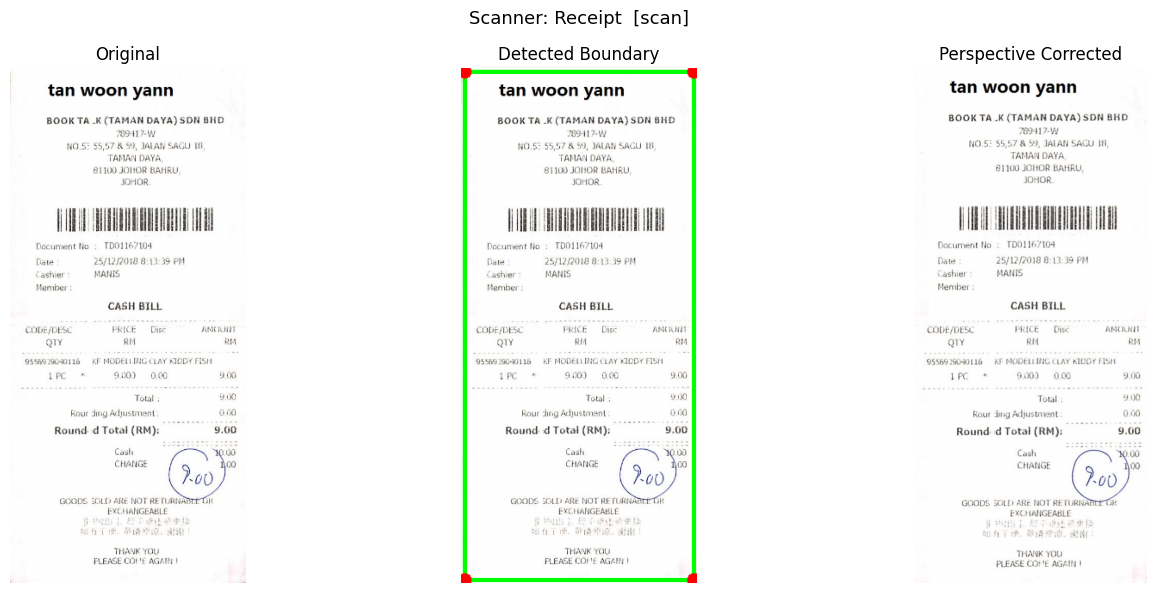


───────────────────────────────────────────────────────
Processing: X00016469619.jpg
───────────────────────────────────────────────────────
  [SCAN] X00016469619.jpg
  ✓ Scan detected — using full image border


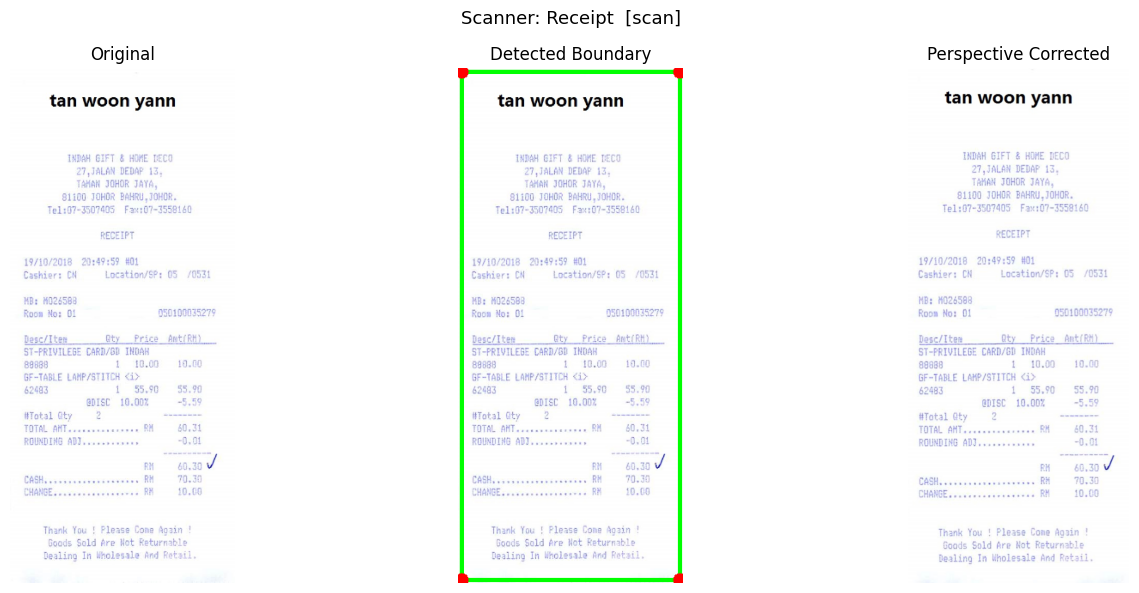


───────────────────────────────────────────────────────
Processing: X00016469620.jpg
───────────────────────────────────────────────────────
  [SCAN] X00016469620.jpg
  ✓ Scan detected — using full image border


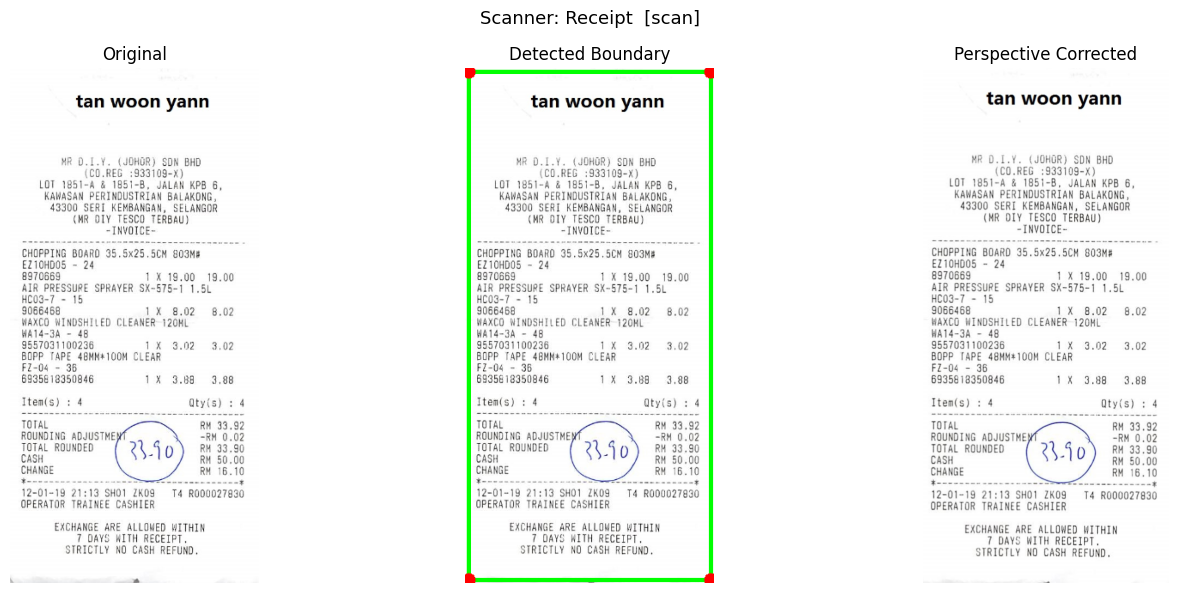


───────────────────────────────────────────────────────
Processing: X00016469622.jpg
───────────────────────────────────────────────────────
  [SCAN] X00016469622.jpg
  ✓ Scan detected — using full image border


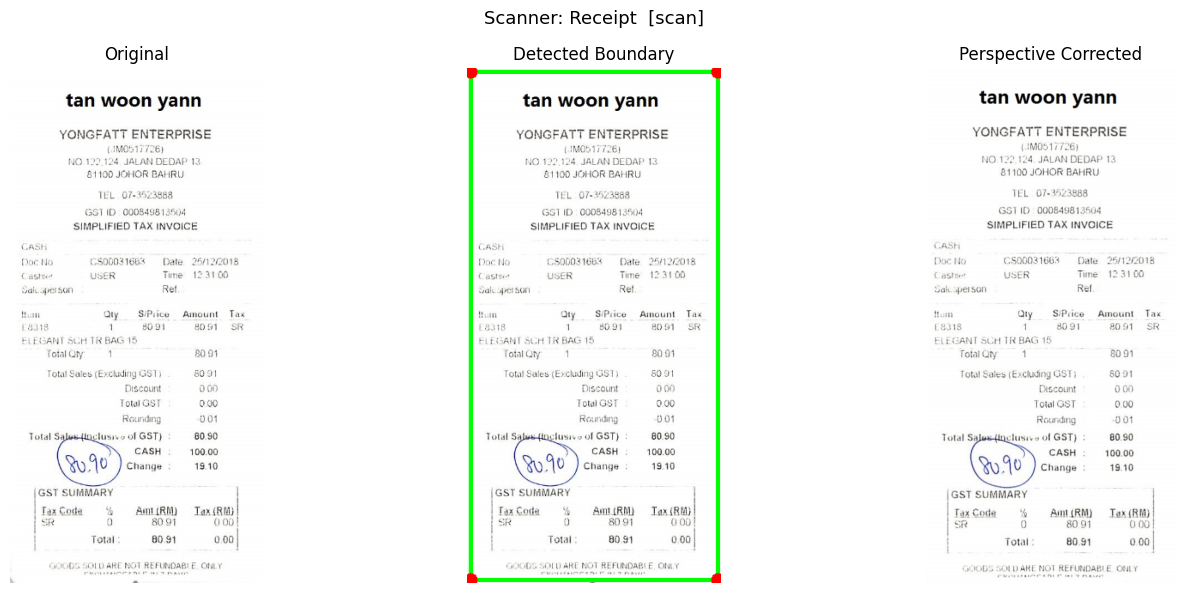


───────────────────────────────────────────────────────
Processing: X00016469623.jpg
───────────────────────────────────────────────────────
  [SCAN] X00016469623.jpg
  ✓ Scan detected — using full image border


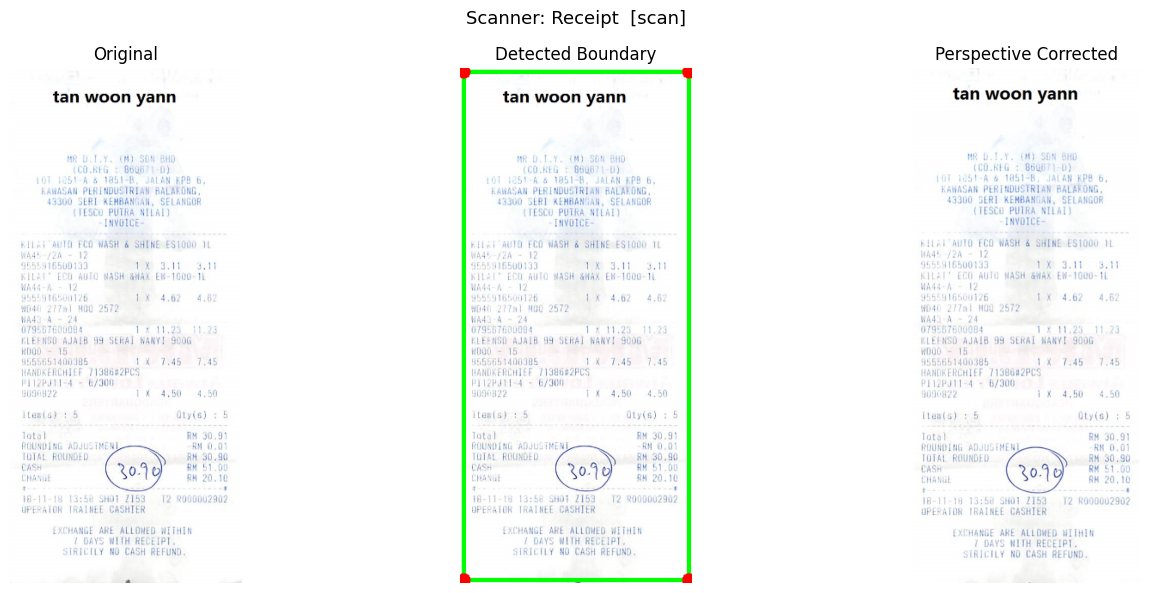

In [36]:
# Download model
model_path = download_model_if_needed()

# Image directory
train_img_dir = "/content/SROIE/SROIE2019/train/img"

# Load image names
imgs = sorted([
    f for f in os.listdir(train_img_dir)
    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.jfif'))
])

print(f"Total images: {len(imgs)}")

# Process first 5 images
for img_name in imgs[:5]:

    img_path = os.path.join(train_img_dir, img_name)

    print(f"\n{'─'*55}")
    print(f"Processing: {img_name}")
    print(f"{'─'*55}")

    process_and_warp_document(
        img_path,
        "Receipt",
        model_path=model_path
    )

# **Image Enhancement**

In [12]:
import random
import cv2
import os
import matplotlib.pyplot as plt

def show_enhanced_images(dataset_path, num_images=2):
    classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

    for cls in classes:
        cls_path = os.path.join(dataset_path, cls)
        images = [img for img in os.listdir(cls_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if not images:
            continue

        sample_images = random.sample(images, min(num_images, len(images)))

        # Create a grid: Rows = number of images, Cols = 2 (Original, Enhanced)
        fig, axes = plt.subplots(len(sample_images), 2, figsize=(12, 5 * len(sample_images)))
        fig.suptitle(f"Class: {cls}", fontsize=18, fontweight='bold')

        # Handle case where only 1 image is sampled (axes becomes 1D array)
        if len(sample_images) == 1:
            axes = np.expand_dims(axes, axis=0)

        for i, img_name in enumerate(sample_images):
            img_path = os.path.join(cls_path, img_name)
            img = cv2.imread(img_path)

            if img is None:
                continue

            enhanced = enhance_image(img)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Plot Original
            axes[i, 0].imshow(img_rgb)
            axes[i, 0].set_title("Original", fontsize=12)
            axes[i, 0].axis("off")

            # Plot Enhanced
            axes[i, 1].imshow(enhanced, cmap='gray')
            axes[i, 1].set_title("Enhanced (Adaptive Threshold)", fontsize=12)
            axes[i, 1].axis("off")

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

In [11]:
import cv2
import numpy as np

def enhance_image(img):
    # 1. Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Rescale/Resize (Optional)
    # If images are very small, text becomes unreadable.
    # Upscaling by 2x can often help OCR/readability.
    gray = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

    # 3. Denoise lightly (keeps edges sharp while removing background grain)
    denoised = cv2.fastNlMeansDenoising(gray, h=10)

    # 4. Adaptive Thresholding
    # This is the "magic" for documents.
    # blockSize=11 and C=2 are good starting points.
    enhanced = cv2.adaptiveThreshold(
        denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2
    )

    # 5. Morphological operations (Optional)
    # If the text is too thin, uncomment the next two lines to thicken it slightly
    kernel = np.ones((1, 1), np.uint8)
    enhanced = cv2.morphologyEx(enhanced, cv2.MORPH_OPEN, kernel)

    return enhanced

In [13]:
# Run the visualization
show_enhanced_images(dataset_path, num_images=2)

# ***Segmentation: Separate Text from Background***

## Overview

After the document boundary is detected and the perspective is corrected, we apply **text-background segmentation** to produce a clean, binarised image where ink pixels are black and the page is white.  

Three complementary strategies are implemented and compared:

| # | Method | When it shines |
|---|--------|----------------|
| 1 | **Adaptive Thresholding** | Uneven lighting, shadows |
| 2 | **Sauvola Local Thresholding** | Low-contrast or faded text |
| 3 | **Morphological Top-Hat + Otsu** | Wrinkled / noisy backgrounds |

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os, random

# ── helpers already defined above (enhance_image, four_point_warp, etc.) ──

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# STRATEGY 1 — Adaptive Gaussian Thresholding
# Best for: uneven illumination, shadows, phone-camera shots
# ─────────────────────────────────────────────────────────────────────────
def segment_adaptive(gray: np.ndarray,
                     block_size: int = 31,
                     C: int = 10) -> np.ndarray:
    """
    Binarise a grayscale document image with adaptive Gaussian thresholding.

    Parameters
    ----------
    gray       : uint8 grayscale image
    block_size : size of the local neighbourhood (must be odd, >=3)
    C          : constant subtracted from the weighted mean

    Returns
    -------
    binary : uint8 image (0 = text / ink,  255 = background / paper)
    """
    # Denoise while keeping edges sharp
    denoised = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)

    binary = cv2.adaptiveThreshold(
        denoised, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        block_size, C
    )
    return binary


# ─────────────────────────────────────────────────────────────────────────
# STRATEGY 2 — Sauvola Local Thresholding
# Best for: low-contrast, faded, or water-damaged text
# ─────────────────────────────────────────────────────────────────────────
def _sauvola_threshold(gray: np.ndarray,
                        window: int = 51,
                        k: float = 0.2,
                        R: float = 128.0) -> np.ndarray:
    """
    Pure-NumPy Sauvola binarisation.

    T(x,y) = mean * (1 + k * (std/R - 1))

    Parameters
    ----------
    gray   : uint8 grayscale image
    window : local window side length (must be odd)
    k      : sensitivity  (0.1 – 0.5; higher → more aggressive)
    R      : dynamic-range constant (128 works for 8-bit images)

    Returns
    -------
    binary : uint8 image (0 = text, 255 = background)
    """
    img = gray.astype(np.float64)
    pad = window // 2
    img_pad = np.pad(img, pad, mode='reflect')

    # Compute local mean and variance via integral images
    integral  = cv2.integral(img_pad)
    integral2 = cv2.integral(img_pad ** 2)

    h, w = gray.shape
    # Slice corners for the sliding sum
    tl = integral[:h,   :w  ]
    tr = integral[:h,   window:w+window]
    bl = integral[window:h+window, :w  ]
    br = integral[window:h+window, window:w+window]

    tl2 = integral2[:h,   :w  ]
    tr2 = integral2[:h,   window:w+window]
    bl2 = integral2[window:h+window, :w  ]
    br2 = integral2[window:h+window, window:w+window]

    N    = window * window
    mean = (br - bl - tr + tl) / N
    sq   = (br2 - bl2 - tr2 + tl2) / N
    std  = np.sqrt(np.maximum(sq - mean**2, 0))

    threshold = mean * (1.0 + k * (std / R - 1.0))
    binary    = np.where(img < threshold, 0, 255).astype(np.uint8)
    return binary


def segment_sauvola(gray: np.ndarray,
                    window: int = 51,
                    k: float = 0.2) -> np.ndarray:
    """
    Sauvola segmentation with a light denoising pre-pass.
    Returns uint8 binary (0=text, 255=background).
    """
    denoised = cv2.GaussianBlur(gray, (3, 3), 0)
    return _sauvola_threshold(denoised, window=window, k=k)


# ─────────────────────────────────────────────────────────────────────────
# STRATEGY 3 — Morphological Top-Hat + Otsu
# Best for: wrinkled pages, non-uniform paper texture, noisy backgrounds
# ─────────────────────────────────────────────────────────────────────────
def segment_tophat_otsu(gray: np.ndarray,
                         kernel_size: int = 25) -> np.ndarray:
    """
    Morphological top-hat transform to flatten background, then Otsu.

    Top-hat = image - morphological_opening(image)
    This removes large-scale background variation, leaving only fine
    bright structures (text strokes on a lighter background).

    Parameters
    ----------
    gray        : uint8 grayscale image
    kernel_size : structuring element size (should be > the widest stroke)

    Returns
    -------
    binary : uint8 image (0 = text, 255 = background)
    """
    kernel  = cv2.getStructuringElement(
        cv2.MORPH_RECT, (kernel_size, kernel_size))

    # Black-hat highlights dark objects (ink) on a bright background
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)

    # Otsu on the black-hat residual
    _, binary_ink = cv2.threshold(
        blackhat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Invert so ink=0, background=255 (same convention as other methods)
    binary = cv2.bitwise_not(binary_ink)
    return binary


# ─────────────────────────────────────────────────────────────────────────
# AUTO-SELECT: pick the best strategy per image
# ─────────────────────────────────────────────────────────────────────────
def auto_segment(gray: np.ndarray) -> tuple[np.ndarray, str]:
    """
    Automatically choose and apply the best segmentation strategy.

    Heuristic
    ---------
    - High std-dev of local means  → uneven lighting  → Adaptive
    - Low global contrast           → faded text       → Sauvola
    - Otherwise                                        → Top-Hat + Otsu

    Returns
    -------
    (binary, method_name)
    """
    # Measure illumination unevenness via std of block means
    h, w = gray.shape
    b    = max(h // 8, 16)
    block_means = []
    for r in range(0, h - b, b):
        for c in range(0, w - b, b):
            block_means.append(gray[r:r+b, c:c+b].mean())
    illumination_std = np.std(block_means)

    global_contrast  = gray.max() - gray.min()

    if illumination_std > 25:
        return segment_adaptive(gray), 'Adaptive Thresholding'
    elif global_contrast < 120:
        return segment_sauvola(gray), 'Sauvola'
    else:
        return segment_tophat_otsu(gray), 'Top-Hat + Otsu'


print('✓ Segmentation functions defined.')

✓ Segmentation functions defined.


In [ ]:
def visualise_segmentation(img_bgr: np.ndarray,
                            title: str = '') -> None:
    """
    Display the original image next to all three segmentation results
    plus the auto-selected output.

    Parameters
    ----------
    img_bgr : colour document image (BGR, uint8)
    title   : optional super-title for the figure
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    results = [
        ('Original',              cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB), False),
        ('Adaptive\nThresholding', segment_adaptive(gray),                  True),
        ('Sauvola\nLocal Thresh.', segment_sauvola(gray),                   True),
        ('Top-Hat\n+ Otsu',        segment_tophat_otsu(gray),               True),
    ]

    auto_bin, auto_name = auto_segment(gray)
    results.append((f'Auto-Selected\n({auto_name})', auto_bin, True))

    fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 6))
    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold')

    for ax, (label, img, is_gray) in zip(axes, results):
        ax.imshow(img, cmap='gray' if is_gray else None)
        ax.set_title(label, fontsize=11)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

print('✓ Visualisation helper defined.')

✓ Visualisation helper defined.


In [ ]:
def full_pipeline(img_path: str,
                   model_path: str = None,
                   show_steps: bool = True) -> np.ndarray:
    """
    End-to-end document scanner pipeline:
      1. Load image
      2. Detect document boundary (U2Net → Classic CV → border fallback)
      3. Perspective-correct the document
      4. Segment text from background (auto-selects best method)

    Parameters
    ----------
    img_path   : path to the input image
    model_path : path to u2net.onnx (optional)
    show_steps : if True, display intermediate results

    Returns
    -------
    clean_bin : binarised document image (uint8, 0=text, 255=bg)
    """
    image = cv2.imread(img_path)
    if image is None:
        raise FileNotFoundError(f'Cannot load: {img_path}')

    # ── Step 1–3: boundary + warp (reuse existing functions) ──────────────
    orig      = image.copy()
    ratio     = image.shape[0] / 600.0
    img_res   = cv2.resize(image, (int(image.shape[1] / ratio), 600))
    h, w      = img_res.shape[:2]
    total_area = h * w
    img_type  = classify_image(img_res)

    final_pts = None
    if model_path and os.path.exists(model_path) and img_type == 'photo':
        try:
            mask      = u2net_segment(img_res, model_path)
            final_pts = quad_from_mask(mask, total_area, img_res.shape)
        except Exception:
            final_pts = None

    if final_pts is None:
        if img_type == 'scan':
            final_pts = border_contour(img_res)
        else:
            mask      = classic_segment(img_res, total_area)
            final_pts = quad_from_mask(mask, total_area, img_res.shape) \
                        if mask is not None else border_contour(img_res)

    warped = four_point_warp(orig, final_pts * ratio)

    # ── Step 4: text-background segmentation ──────────────────────────────
    gray_warped          = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
    clean_bin, seg_name  = auto_segment(gray_warped)

    if show_steps:
        fig, axes = plt.subplots(1, 4, figsize=(20, 6))
        fig.suptitle(
            f'{os.path.basename(img_path)}  [{img_type}]  '
            f'segmentation: {seg_name}',
            fontsize=12, fontweight='bold'
        )

        axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Original'); axes[0].axis('off')

        axes[1].imshow(cv2.cvtColor(img_res, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f'Resized [{img_type}]'); axes[1].axis('off')

        axes[2].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
        axes[2].set_title('Perspective Corrected'); axes[2].axis('off')

        axes[3].imshow(clean_bin, cmap='gray')
        axes[3].set_title(f'Text Segmented\n({seg_name})'); axes[3].axis('off')

        plt.tight_layout()
        plt.show()

    return clean_bin


print('✓ Full pipeline with segmentation defined.')

✓ Full pipeline with segmentation defined.


In [ ]:
# ── Run segmentation comparison on the dataset ────────────────────────────

categories = [
    d for d in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, d))
]

for cls in categories:
    cls_path = os.path.join(dataset_path, cls)
    imgs = sorted([
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.jfif'))
    ])

    print(f"\n{'─'*60}")
    print(f"Category: {cls}  (showing first 2 images)")
    print(f"{'─'*60}")

    for img_name in imgs[:2]:
        img_path = os.path.join(cls_path, img_name)
        img_bgr  = cv2.imread(img_path)
        if img_bgr is None:
            continue

        # Show all three strategies + auto-select side-by-side
        visualise_segmentation(img_bgr, title=f'{cls} — {img_name}')


Processing: Email/527820130+-0130.jpg


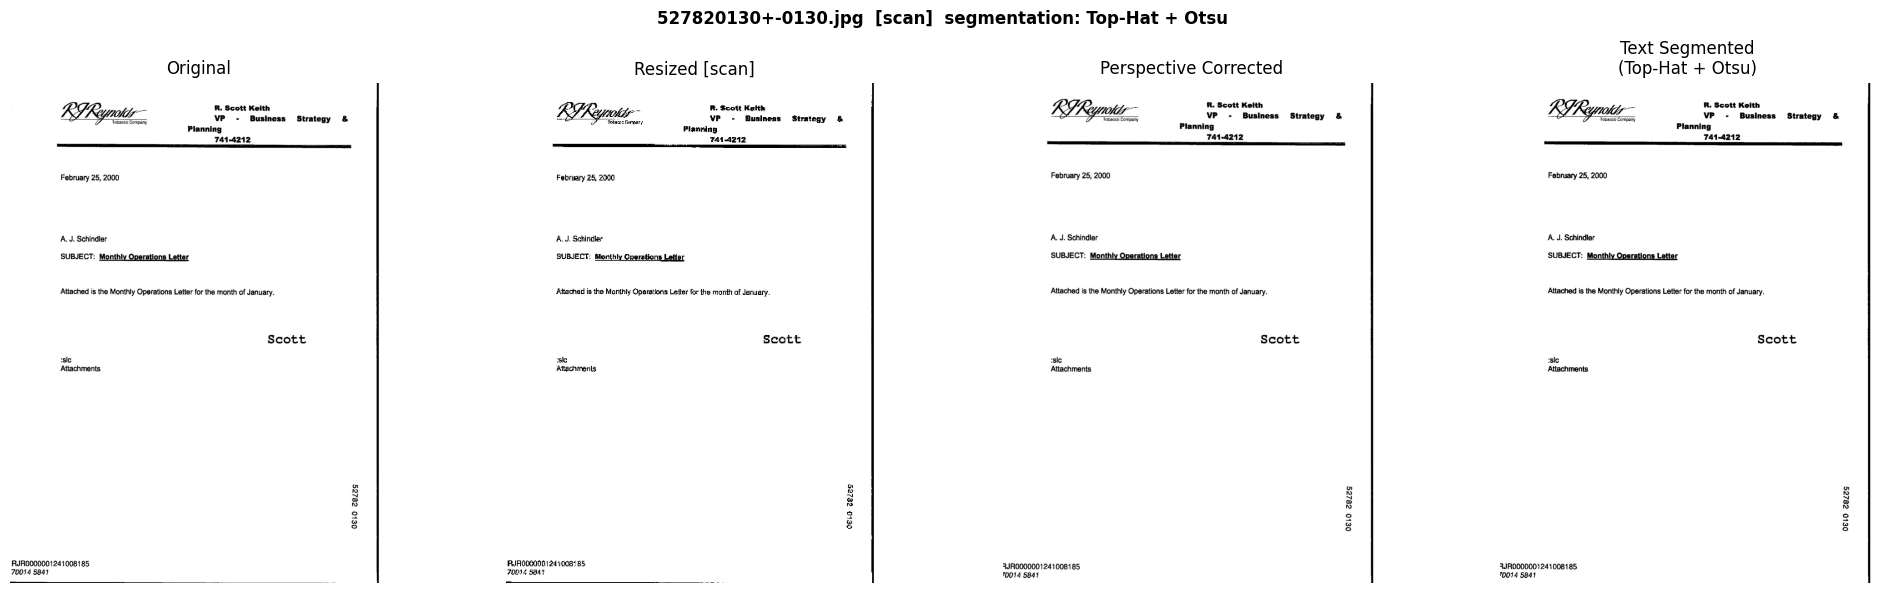

  Output shape: (2261, 1696),  text pixels: 104,816

Processing: Invoice/canva-fashion-invoice-zvoLwRH8Wys.png


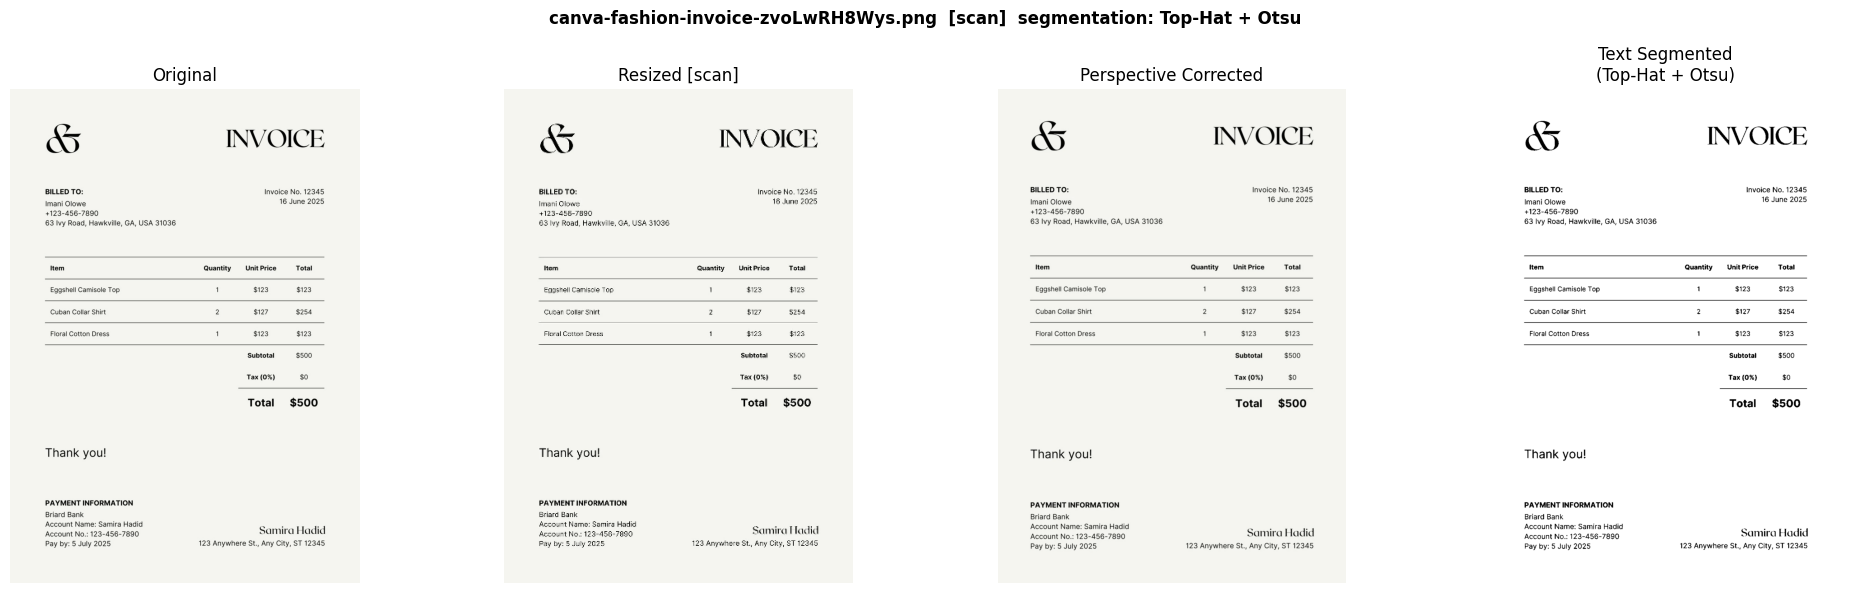

  Output shape: (1578, 1109),  text pixels: 47,636

Processing: Receipt/1751036667490.jpg


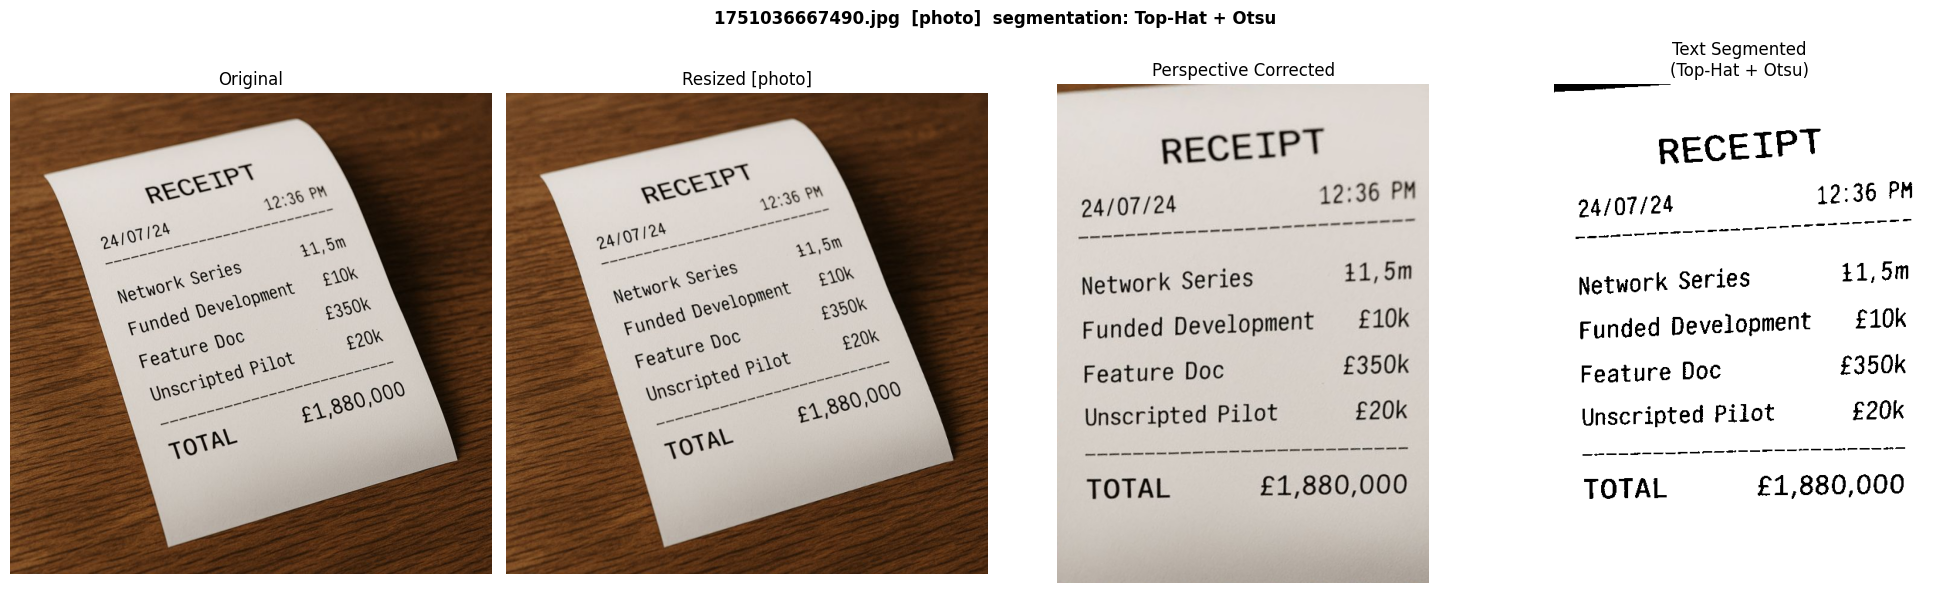

  Output shape: (647, 482),  text pixels: 18,642

Processing: Letter/11019361.jpg


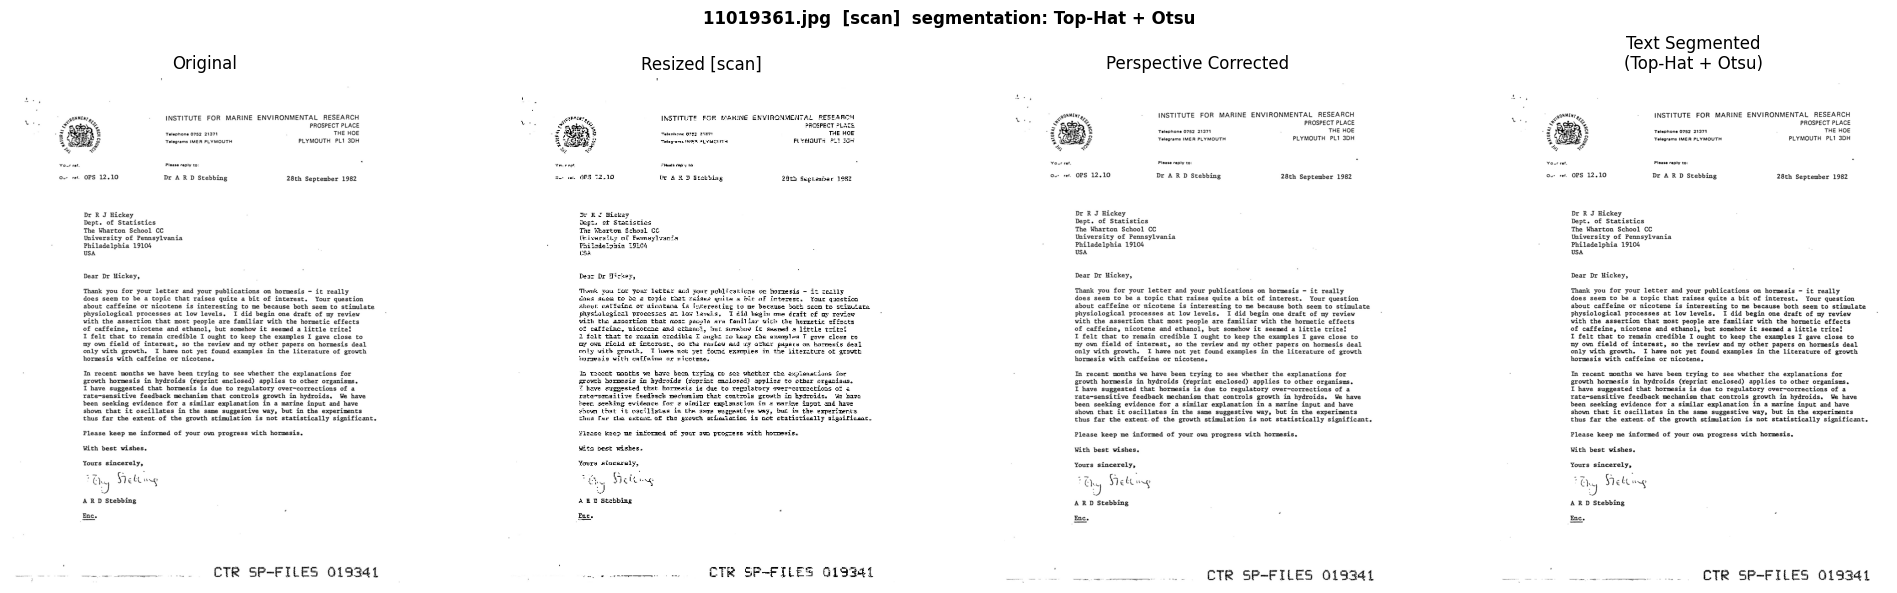

  Output shape: (3256, 2497),  text pixels: 397,737

Processing: Menu/Elegant Wedding Menu Cards  - Canva Template.jfif


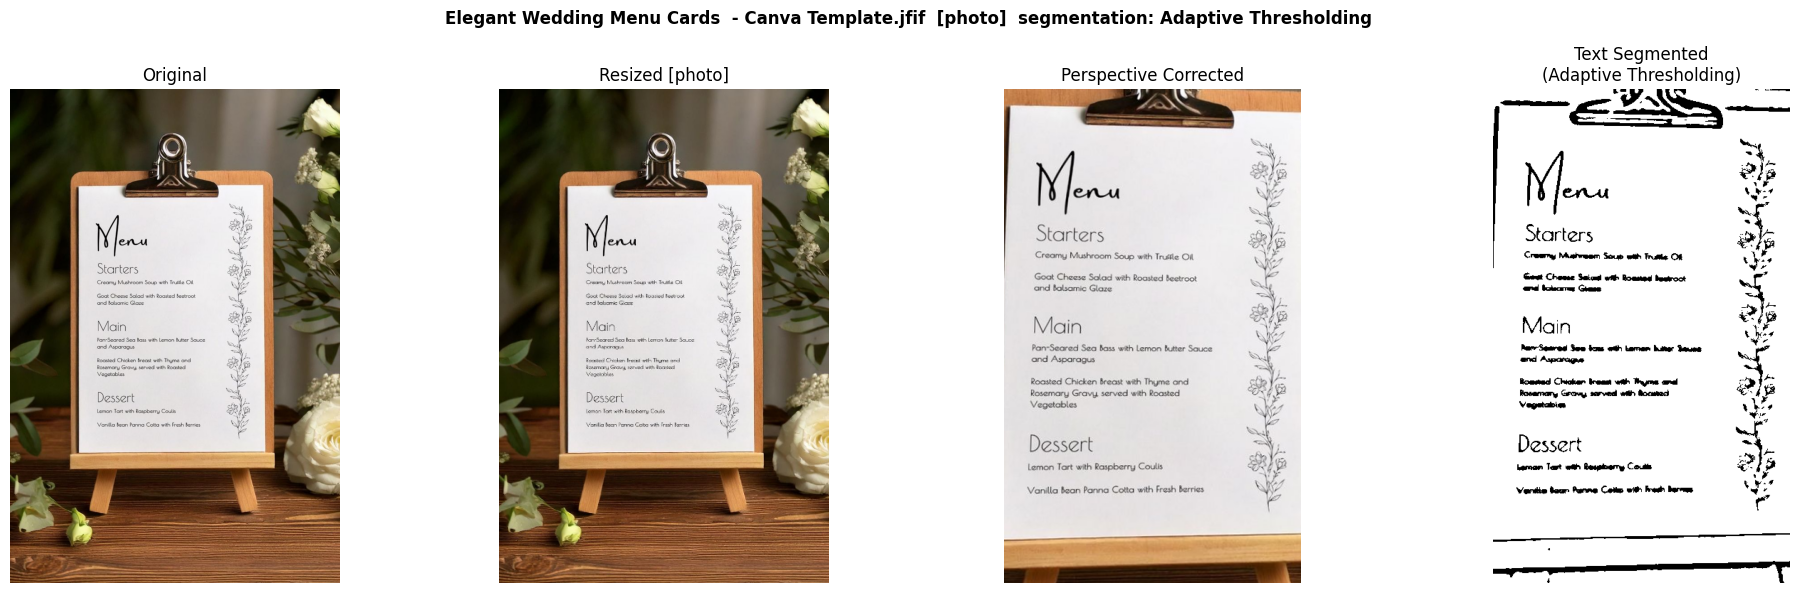

  Output shape: (695, 417),  text pixels: 27,602


In [ ]:
# ── Full end-to-end pipeline (boundary + warp + segmentation) ────────────
# model_path was defined earlier by download_model_if_needed()

for cls in categories:
    cls_path = os.path.join(dataset_path, cls)
    imgs = sorted([
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.jfif'))
    ])

    for img_name in imgs[:1]:          # one image per category
        img_path = os.path.join(cls_path, img_name)
        print(f'\nProcessing: {cls}/{img_name}')
        clean = full_pipeline(img_path, model_path=model_path, show_steps=True)
        print(f'  Output shape: {clean.shape},  '
              f'text pixels: {(clean == 0).sum():,}')

# ***OCR: Optical Character Recognition***



## Install Tesseract & pytesseract

In [ ]:
!apt-get install -y tesseract-ocr tesseract-ocr-ara 2>/dev/null | tail -1
!pip install pytesseract -q

import pytesseract
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os, re
from PIL import Image

print('Tesseract version:', pytesseract.get_tesseract_version())
print('✓ pytesseract ready')

Setting up tesseract-ocr-ara (1:4.00~git30-7274cfa-1.1) ...
Tesseract version: 4.1.1
✓ pytesseract ready


## OCR Helper Functions

In [ ]:
import re
import pytesseract
from PIL import Image


OCR_CONFIGS = {
    "full_page":    r"--oem 3 --psm 3",   # default: full document
    "single_block": r"--oem 3 --psm 6",   # uniform text block
    "sparse_text":  r"--oem 3 --psm 11",  # forms / receipts
}
OCR_CONFIG = OCR_CONFIGS["full_page"]     # default used by run_ocr()


def deskew(binary_img: np.ndarray) -> np.ndarray:

    inv = cv2.bitwise_not(binary_img)
    coords = np.column_stack(np.where(inv > 0))
    if len(coords) < 100:
        return binary_img

    angle = 0.0
    try:
        rect = cv2.minAreaRect(coords)
        angle = rect[-1]
        if angle < -45:
            angle += 90
    except Exception:
        return binary_img

    if abs(angle) > 10:
        return binary_img

    h, w = binary_img.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    rotated = cv2.warpAffine(
        binary_img, M, (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=255
    )
    return rotated


def preprocess_for_ocr(binary_img: np.ndarray) -> np.ndarray:

    img = binary_img.copy()

    # Ensure binary
    if img.max() != 255 or img.min() != 0:
        _, img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # Deskew
    img = deskew(img)

    # Upscale small images
    h, w = img.shape[:2]
    if max(h, w) < 1000:
        scale = 1000 / max(h, w)
        img = cv2.resize(img, None, fx=scale, fy=scale,
                         interpolation=cv2.INTER_CUBIC)

    # Median blur — safer than morphological open for thin strokes
    img = cv2.medianBlur(img, 3)

    # White border to prevent Tesseract clipping
    img = cv2.copyMakeBorder(img, 20, 20, 20, 20,
                              cv2.BORDER_CONSTANT, value=255)
    return img


def run_ocr(binary_img: np.ndarray,
             lang: str = 'eng',
             config: str = None) -> str:

    if config is None:
        config = OCR_CONFIG
    ready = preprocess_for_ocr(binary_img)
    from PIL import Image as PILImage
    pil_img = PILImage.fromarray(ready)
    return pytesseract.image_to_string(pil_img, lang=lang, config=config)


def clean_ocr_text(raw: str) -> str:

    lines = raw.split('\n')
    cleaned = []
    prev_blank = False
    for line in lines:
        line = line.strip()
        if not re.search(r'[A-Za-z0-9\u0600-\u06FF]', line):
            if not prev_blank and cleaned:
                cleaned.append('')
            prev_blank = True
        else:
            cleaned.append(line)
            prev_blank = False
    return '\n'.join(cleaned).strip()


print('OCR helper functions defined.')
print(f'  PSM configs available: {list(OCR_CONFIGS.keys())}')
print('  Deskew correction: enabled')


OCR helper functions defined.
  PSM configs available: ['full_page', 'single_block', 'sparse_text']
  Deskew correction: enabled


## Full OCR Pipeline (per image)

In [ ]:
def ocr_pipeline(img_path: str,
                  model_path: str = None,
                  lang: str = 'eng',
                  show: bool = True) -> dict:

    # Steps 1-3: boundary + warp + segmentation (reuse full_pipeline)
    binary = full_pipeline(img_path, model_path=model_path, show_steps=False)

    # Step 4-5: OCR
    raw_text   = run_ocr(binary, lang=lang)
    clean_text = clean_ocr_text(raw_text)

    if show:
        orig = cv2.imread(img_path)
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle(
            f'{os.path.basename(img_path)}',
            fontsize=13, fontweight='bold'
        )

        axes[0].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Original Image'); axes[0].axis('off')

        axes[1].imshow(binary, cmap='gray')
        axes[1].set_title('Segmented (OCR Input)'); axes[1].axis('off')

        preview = clean_text[:600] + ('...' if len(clean_text) > 600 else '')
        axes[2].text(
            0.01, 0.99, preview if preview.strip() else '[No text detected]',
            transform=axes[2].transAxes,
            fontsize=7, verticalalignment='top', fontfamily='monospace',
            wrap=True,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
        )
        axes[2].set_title('Extracted Text (preview)'); axes[2].axis('off')

        plt.tight_layout()
        plt.show()

        print(f'\n--- Extracted Text ---\n{clean_text[:1000]}\n')

    return {
        'raw_text':   raw_text,
        'clean_text': clean_text,
        'binary_img': binary
    }


print('✓ Full OCR pipeline defined.')


✓ Full OCR pipeline defined.


## Run OCR on Dataset

In [ ]:
# Run OCR pipeline on the first 2 images of each category

ocr_results = {}   # {img_path: result_dict}

categories = [
    d for d in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, d))
]

for cls in categories:
    cls_path = os.path.join(dataset_path, cls)
    imgs = sorted([
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.jfif'))
    ])

    if not imgs:
        continue

    print(f"\n{'═'*60}")
    print(f"Category: {cls}  (processing first {min(2, len(imgs))} image(s))")
    print(f"{'═'*60}")

    for img_name in imgs[:2]:
        img_path = os.path.join(cls_path, img_name)
        result   = ocr_pipeline(img_path, model_path=model_path,
                                 lang='eng', show=True)
        ocr_results[img_path] = result

print(f"\n✓ OCR complete for {len(ocr_results)} images.")


In [ ]:
# SAVE OCR RESULTS AS .txt FILES
# Deliverable: one .txt file per document image with extracted clean text.

ocr_text_dir = "/content/ocr_text_outputs"
os.makedirs(ocr_text_dir, exist_ok=True)

for img_path, result in ocr_results.items():
    img_name = os.path.splitext(os.path.basename(img_path))[0]
    txt_path = os.path.join(ocr_text_dir, img_name + ".txt")

    with open(txt_path, "w", encoding="utf-8") as f:
        f.write(f"Image   : {os.path.basename(img_path)}\n")
        f.write("-" * 50 + "\n\n")
        f.write(result["clean_text"])

    print(f"Saved: {txt_path}")

print(f"\nAll OCR text files saved to: {ocr_text_dir}")

Saved: /content/ocr_text_outputs/527820130+-0130.txt
Saved: /content/ocr_text_outputs/Level up your brand with email template Mailchimp free.txt
Saved: /content/ocr_text_outputs/canva-fashion-invoice-zvoLwRH8Wys.txt
Saved: /content/ocr_text_outputs/z1.txt
Saved: /content/ocr_text_outputs/1751036667490.txt
Saved: /content/ocr_text_outputs/11019361.txt
Saved: /content/ocr_text_outputs/HOME.txt
Saved: /content/ocr_text_outputs/Elegant Wedding Menu Cards  - Canva Template.txt

All OCR text files saved to: /content/ocr_text_outputs
